In [1]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd

one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from ibl_info.prepare_data_pid import get_new_cinc_intervals

/Users/kschille/micromamba/envs/info-decom/lib/python3.12/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


50 sessions with widefield data found


In [12]:
details

[{'id': 'f7d46a15-9498-40dc-90da-fb977ce844be',
  'subject': 'CSK-im-009',
  'start_time': '2021-07-29T08:52:35.301299',
  'number': 1,
  'lab': 'zadorlab',
  'projects': ['zador_les'],
  'url': 'https://openalyx.internationalbrainlab.org/sessions/f7d46a15-9498-40dc-90da-fb977ce844be',
  'task_protocol': '_iblrig_tasks_widefieldChoiceWorld6.4.2',
  'date': datetime.date(2021, 7, 29)}]

In [5]:
from matplotlib import pyplot as plt

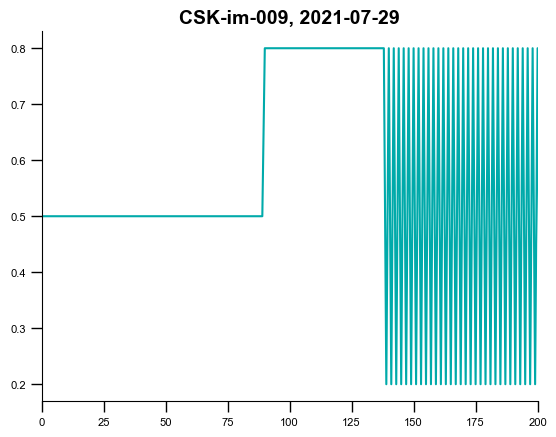

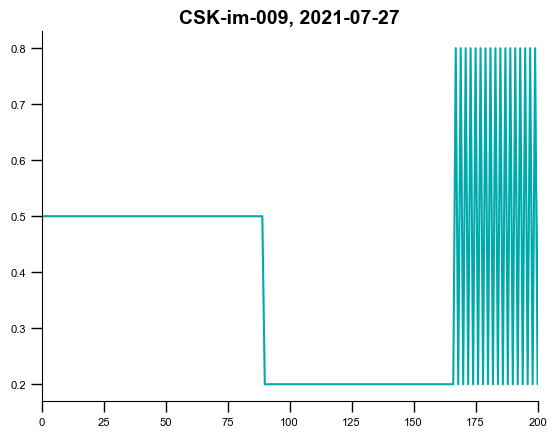

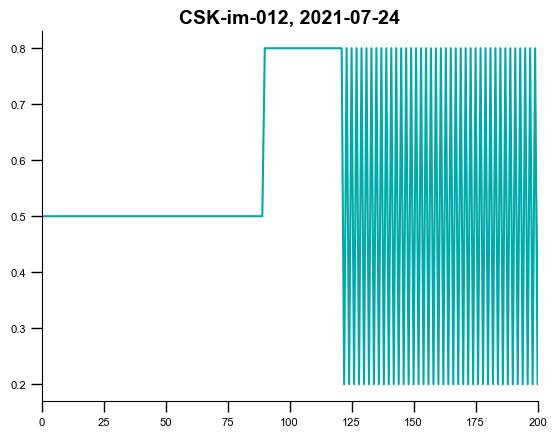

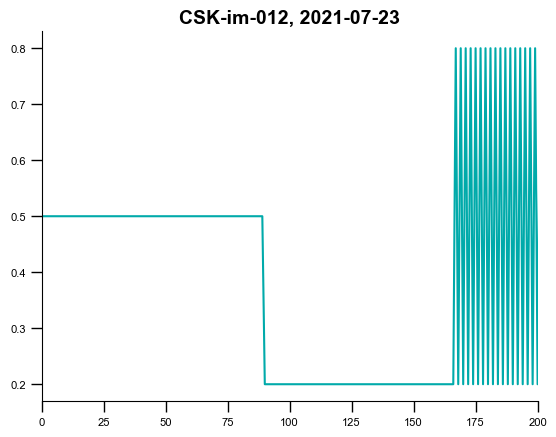

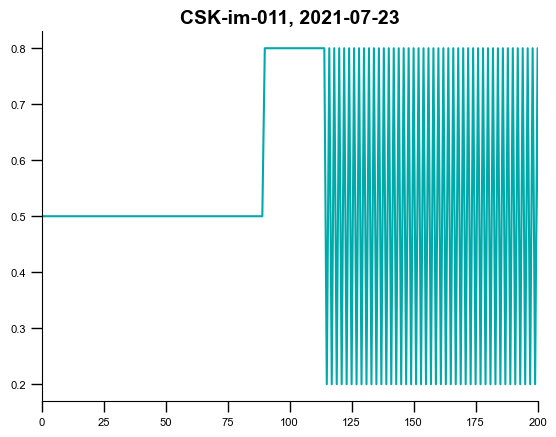

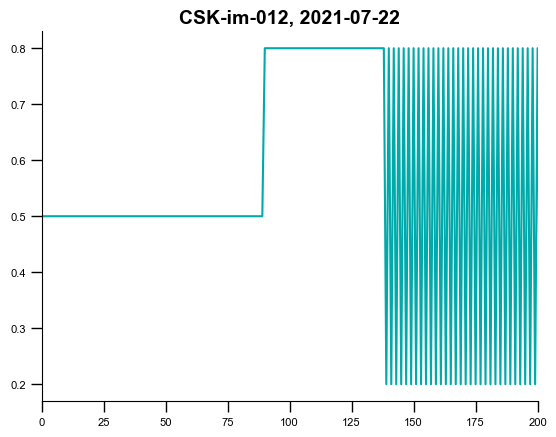

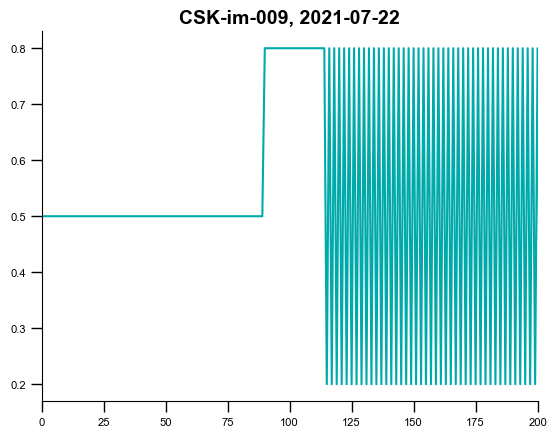

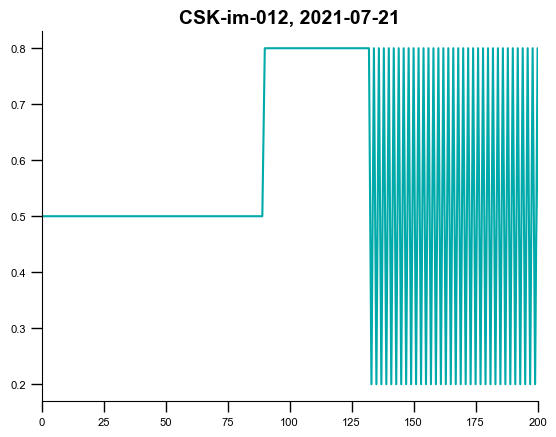

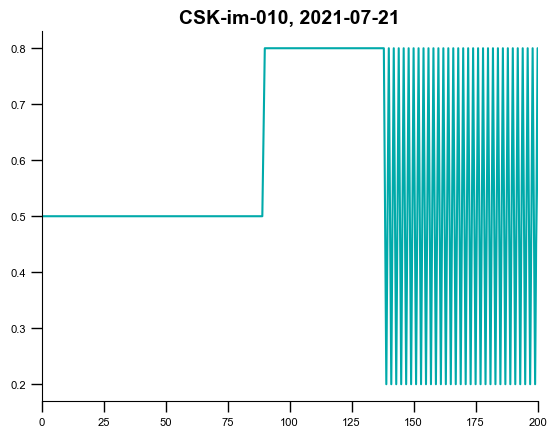

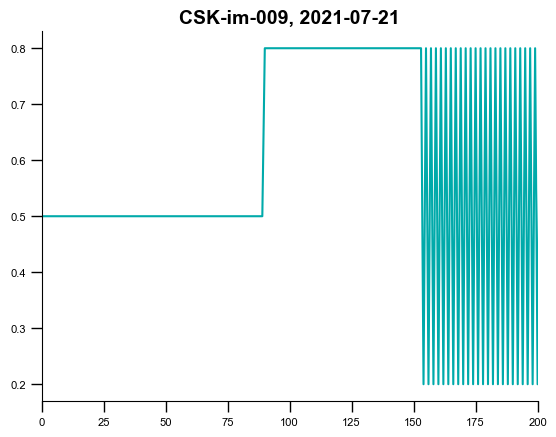

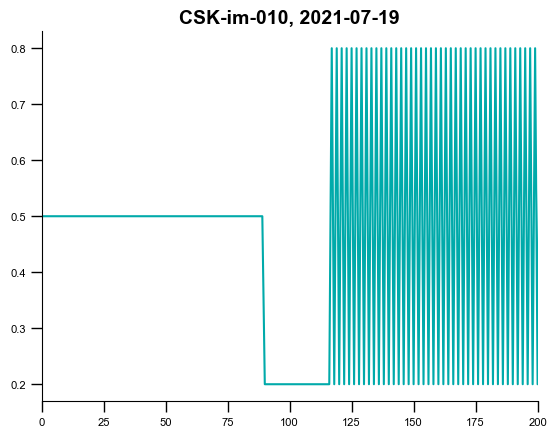

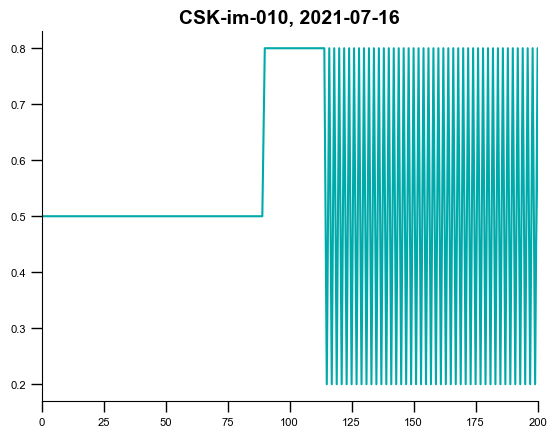

In [14]:
for idx in range(len(sessions)):
    session_id = sessions[idx]
    sl = SessionLoader(one, eid=session_id)
    sl.load_trials()
    trials_mask = compute_mask(
        sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
    )
    if sum(trials_mask) <= 1:
        raise ValueError(f"Session {session_id} has {sum(trials_mask)} good trials, less than 1.")
    plt.plot(sl.trials.probabilityLeft, c="#00aaaa")
    plt.xlim(0, 200)
    _, details = one.search(id=session_id, details=True)
    plt.title(f"{details[0]["subject"]}, {details[0]['date']}")
    plt.show()
    if idx > 10:
        break

In [76]:
hemisphere = ("left", "right")
align_event = "stimOn_times"
min_rt = 0.08
max_rt = None
frame_window = (-2, 2)  # this is unnecessary; should be 2 to 0 imo


def check_config():
    """Load config yaml and perform some basic checks"""
    # Get config
    with open(Path(os.getcwd()).parent.joinpath("config.yaml"), "r") as config_yml:
        config = yaml.safe_load(config_yml)
    return config


config = check_config()

# we can pass the proper align times :)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

_, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(trials, "stim")

In [77]:
target_variable.shape

(263,)

In [78]:
align_times = trials["stimOn_times"].values

In [54]:
data_epoch, actual_regions = prepare_widefield(
    one,
    session_id,
    hemisphere,
    regions="single_regions",
    align_times=align_times,
    frame_window=frame_window,
    functional_channel=470,
    stage_only=False,
)

(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSK-im-009/2021-07-27/001/alf/widefield/widefieldSVT.haemoCorrected.npy: 100%|██████████| 59.6M/59.6M [00:03<00:00, 17.5MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSK-im-009/2021-07-27/001/alf/widefield/widefieldU.images.npy: 100%|██████████| 276M/276M [00:09<00:00, 29.5MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSK-im-009/2021-07-27/001/alf/widefield/imaging.imagingLightSource.npy: 100%|██████████| 1.19M/1.19M [00:00<00:00, 1.30MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSK-im-009/2021-07-27/001/alf/widefield/imagingLightSource.properties.htsv: 100%|██████████| 61.0/61.0 [00:00<00:00, 153B/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSK-im-009/2021-07-27/001/alf/widefield/widefieldLandmarks.dorsalCort

In [ ]:
# this should load up the regions
# then we get a frame for each region
# discretize and then for each voxel in a region
# do inter and intra region pid
# also correlation because why not;
# should be super quick
# figure out how to get trial information
# do MI and pid
# figure out the flow

In [84]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

50 sessions with widefield data found


In [91]:
X = one.search(id=sessions[0], details=True)

In [92]:
X

([UUID('f7d46a15-9498-40dc-90da-fb977ce844be')],
 [{'id': 'f7d46a15-9498-40dc-90da-fb977ce844be',
   'subject': 'CSK-im-009',
   'start_time': '2021-07-29T08:52:35.301299',
   'number': 1,
   'lab': 'zadorlab',
   'projects': ['zador_les'],
   'url': 'https://openalyx.internationalbrainlab.org/sessions/f7d46a15-9498-40dc-90da-fb977ce844be',
   'task_protocol': '_iblrig_tasks_widefieldChoiceWorld6.4.2',
   'date': datetime.date(2021, 7, 29)}])

(0.0, 200.0)

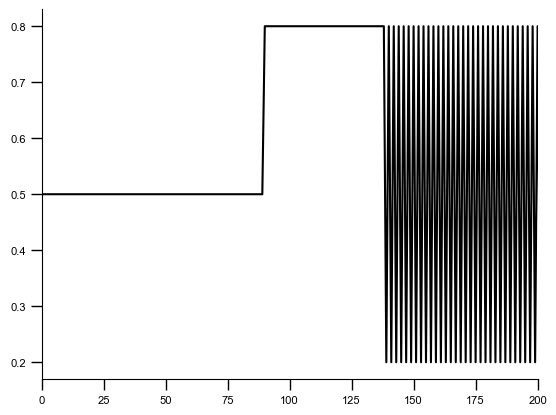

In [100]:
tag = "2023_Q3_Findling_Hubert_et_al"

In [101]:
eids = one.search(django="data_dataset_session_related__tags__name," + tag, query_type="remote")

In [8]:
animals = []
for sid in sessions:
    result = one.search(id=sid, details=True)
    animals.append(result[1][0]["subject"])

In [60]:
sid = "ff7a70f5-a2b6-4e7e-938e-e7208e0678c2"

In [61]:
sl = SessionLoader(one, eid=sid)
sl.load_trials()

In [62]:
one.search(id=sid, details=True)

([UUID('ff7a70f5-a2b6-4e7e-938e-e7208e0678c2')],
 [{'id': 'ff7a70f5-a2b6-4e7e-938e-e7208e0678c2',
   'subject': 'CSK-im-009',
   'start_time': '2021-06-15T13:04:31.609864',
   'number': 1,
   'lab': 'zadorlab',
   'projects': ['zador_les'],
   'url': 'https://openalyx.internationalbrainlab.org/sessions/ff7a70f5-a2b6-4e7e-938e-e7208e0678c2',
   'task_protocol': '_iblrig_tasks_widefieldChoiceWorld6.4.2',
   'date': datetime.date(2021, 6, 15)}])

Text(0.5, 0, 'Trials')

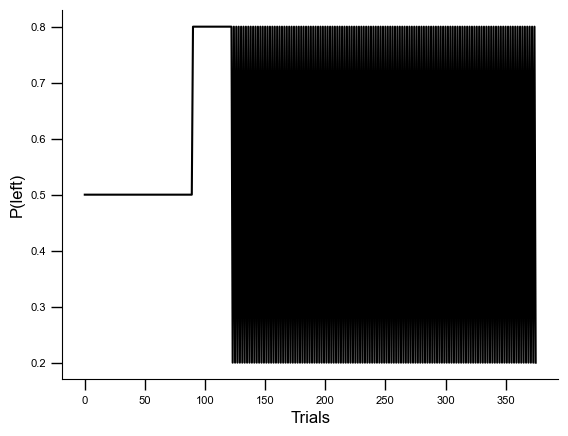

In [68]:
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)

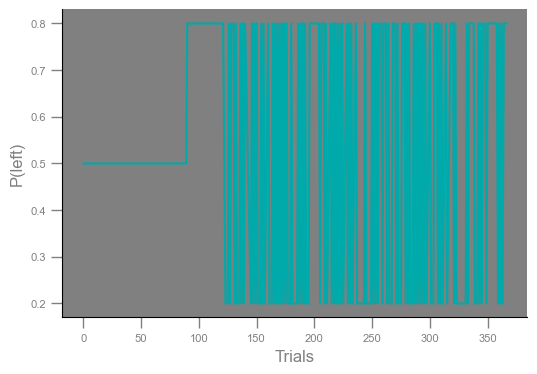

In [84]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")


# same eid used in the test_decoding.py, just to be sure
# also exists in sessions.
sid = "ff7a70f5-a2b6-4e7e-938e-e7208e0678c2"
sl = SessionLoader(one, eid=sid)
sl.load_trials()
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sl.trials.probabilityLeft[trials_mask], c="#00aaaa")
ax.set_ylabel("P(left)")
ax.set_xlabel("Trials")
ax.set_facecolor("grey")
ax.tick_params(axis="x", colors="grey")
ax.tick_params(axis="y", colors="grey")
ax.xaxis.label.set_color("grey")
ax.yaxis.label.set_color("grey")

In [85]:
one.search(id=sid, details=True)

([UUID('ff7a70f5-a2b6-4e7e-938e-e7208e0678c2')],
 [{'id': 'ff7a70f5-a2b6-4e7e-938e-e7208e0678c2',
   'subject': 'CSK-im-009',
   'start_time': '2021-06-15T13:04:31.609864',
   'number': 1,
   'lab': 'zadorlab',
   'projects': ['zador_les'],
   'url': 'https://openalyx.internationalbrainlab.org/sessions/ff7a70f5-a2b6-4e7e-938e-e7208e0678c2',
   'task_protocol': '_iblrig_tasks_widefieldChoiceWorld6.4.2',
   'date': datetime.date(2021, 6, 15)}])